<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Implementasi_REST_API_untuk_Klasifikasi_Emosi_Ulasan_Produk_Indonesia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# =============================================================================
# Program Title     : Stable Environment Setup for PRDECT-ID CSV Workflow
# Short Description : This cell installs stable libraries for a reproducible
#                     machine learning workflow without relying on deprecated
#                     Hugging Face dataset loading scripts.
# =============================================================================

# Keterangan:
# Loader SEACrowd/prdect_id berbasis script .py tidak lagi stabil pada versi
# terbaru Hugging Face datasets. Oleh sebab itu, workflow penelitian ini
# dialihkan ke pembacaan CSV langsung agar lebih stabil, transparan, dan
# dapat direproduksi di Google Colab.

!pip -q install -U \
    pandas \
    numpy \
    scikit-learn \
    matplotlib \
    seaborn \
    joblib \
    tensorflow \
    fastapi \
    uvicorn \
    nest_asyncio \
    requests

print("Installation completed successfully.")

Installation completed successfully.


In [14]:
# =============================================================================
# Program Title: Library Import and Reproducibility Configuration
# =============================================================================

# Keterangan:
# Cell ini mengimpor pustaka utama, mengatur seed agar eksperimen lebih
# reproduktif, serta menyiapkan direktori untuk menyimpan model, tabel, dan grafik.

import os
import re
import json
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from IPython.display import display, Markdown

from datasets import load_dataset, ClassLabel

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Directory setup
BASE_DIR = "/content/prdect_emotion_research"
CACHE_DIR = f"{BASE_DIR}/hf_cache"
ARTIFACT_DIR = f"{BASE_DIR}/artifacts"
FIGURE_DIR = f"{BASE_DIR}/figures"
TABLE_DIR = f"{BASE_DIR}/tables"

for directory in [BASE_DIR, CACHE_DIR, ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR]:
    os.makedirs(directory, exist_ok=True)

display(Markdown("## Environment Setup Completed"))
print("Base directory:", BASE_DIR)
print("TensorFlow version:", tf.__version__)

## Environment Setup Completed

Base directory: /content/prdect_emotion_research
TensorFlow version: 2.21.0


In [15]:
# =============================================================================
# Program Title     : PRDECT-ID Dataset Loading from CSV with Local Cache
# Short Description : This cell loads the PRDECT-ID dataset from a CSV source,
#                     stores it locally, and reuses the local file to avoid
#                     repeated downloads.
# =============================================================================

# Keterangan:
# Cell ini menggantikan load_dataset("SEACrowd/prdect_id") karena loader tersebut
# tidak kompatibel pada environment terbaru. Data dibaca dari file CSV PRDECT-ID
# agar pipeline penelitian tetap berjalan secara stabil dan dapat direproduksi.

import os
import requests
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("## Dataset Loading"))

BASE_DIR = "/content/prdect_emotion_research"
DATA_DIR = f"{BASE_DIR}/data"
CACHE_DIR = f"{BASE_DIR}/hf_cache"
ARTIFACT_DIR = f"{BASE_DIR}/artifacts"
FIGURE_DIR = f"{BASE_DIR}/figures"
TABLE_DIR = f"{BASE_DIR}/tables"

for directory in [BASE_DIR, DATA_DIR, CACHE_DIR, ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR]:
    os.makedirs(directory, exist_ok=True)

# Sumber CSV alternatif yang stabil.
# Catatan integritas:
# Ini bukan loader script SEACrowd, tetapi file CSV PRDECT-ID yang tersedia
# dalam repository Hugging Face lain dalam format tabular.
CSV_URL = "https://huggingface.co/datasets/ZakyF/PRDECT-ID/resolve/main/PRDECT-ID%20Dataset.csv"

LOCAL_CSV_PATH = f"{DATA_DIR}/PRDECT-ID_Dataset.csv"

# Unduh hanya jika file belum ada di penyimpanan lokal Colab
if not os.path.exists(LOCAL_CSV_PATH):
    print("Local dataset file not found. Downloading PRDECT-ID CSV...")

    response = requests.get(CSV_URL, timeout=60)

    if response.status_code != 200:
        raise RuntimeError(
            f"Dataset download failed. HTTP status code: {response.status_code}"
        )

    with open(LOCAL_CSV_PATH, "wb") as file:
        file.write(response.content)

    print("Dataset downloaded and saved locally.")
else:
    print("Local dataset file found. Loading dataset from local cache.")

# Baca CSV dengan fallback encoding agar lebih tahan error
try:
    df = pd.read_csv(LOCAL_CSV_PATH)
except UnicodeDecodeError:
    df = pd.read_csv(LOCAL_CSV_PATH, encoding="latin1")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(Markdown("### Dataset Preview"))
display(df.head())

display(Markdown("### Dataset Columns"))
print(list(df.columns))

# =============================================================================
# Column Detection
# =============================================================================

# Keterangan:
# Deteksi kolom dibuat adaptif karena nama kolom dapat berbeda antara sumber data.
# Program akan mencari kolom teks dan label emosi secara otomatis berdasarkan
# kandidat nama kolom yang paling umum pada dataset PRDECT-ID.

candidate_text_columns = [
    "Customer Review",
    "customer_review",
    "Review",
    "review",
    "Text",
    "text",
    "sentence",
    "content"
]

candidate_label_columns = [
    "Emotion",
    "emotion",
    "Label",
    "label",
    "labels",
    "class"
]

TEXT_COL = None
LABEL_COL = None

for column in candidate_text_columns:
    if column in df.columns:
        TEXT_COL = column
        break

for column in candidate_label_columns:
    if column in df.columns:
        LABEL_COL = column
        break

if TEXT_COL is None:
    raise ValueError(
        "Text column was not found automatically. "
        f"Available columns: {list(df.columns)}"
    )

if LABEL_COL is None:
    raise ValueError(
        "Emotion label column was not found automatically. "
        f"Available columns: {list(df.columns)}"
    )

# Standarisasi tipe data
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Detected text column:", TEXT_COL)
print("Detected label column:", LABEL_COL)
print("Unique labels:", sorted(df[LABEL_COL].dropna().unique()))

display(Markdown("### Final Dataset Information"))
print("Total records:", len(df))
print("Text column:", TEXT_COL)
print("Label column:", LABEL_COL)
print("Number of emotion classes:", df[LABEL_COL].nunique())

## Dataset Loading

Local dataset file not found. Downloading PRDECT-ID CSV...
Dataset downloaded and saved locally.
Dataset loaded successfully.
Dataset shape: (5400, 11)


### Dataset Preview

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


### Dataset Columns

['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion']
Detected text column: Customer Review
Detected label column: Emotion
Unique labels: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']


### Final Dataset Information

Total records: 5400
Text column: Customer Review
Label column: Emotion
Number of emotion classes: 5


## Exploratory Data Analysis

### Dataset Overview

,Metric,Value
0,Total Records,5400
1,Total Columns,13
2,Text Column,Customer Review
3,Label Column,Emotion
4,Number of Classes,5
5,Missing Text Values,0
6,Missing Label Values,0
7,Duplicate Text Records,95


### Emotion Class Distribution

,Emotion Label,Frequency,Percentage
0,Happy,1770,32.78
1,Sadness,1202,22.26
2,Fear,920,17.04
3,Love,809,14.98
4,Anger,699,12.94


Imbalance ratio: 2.532


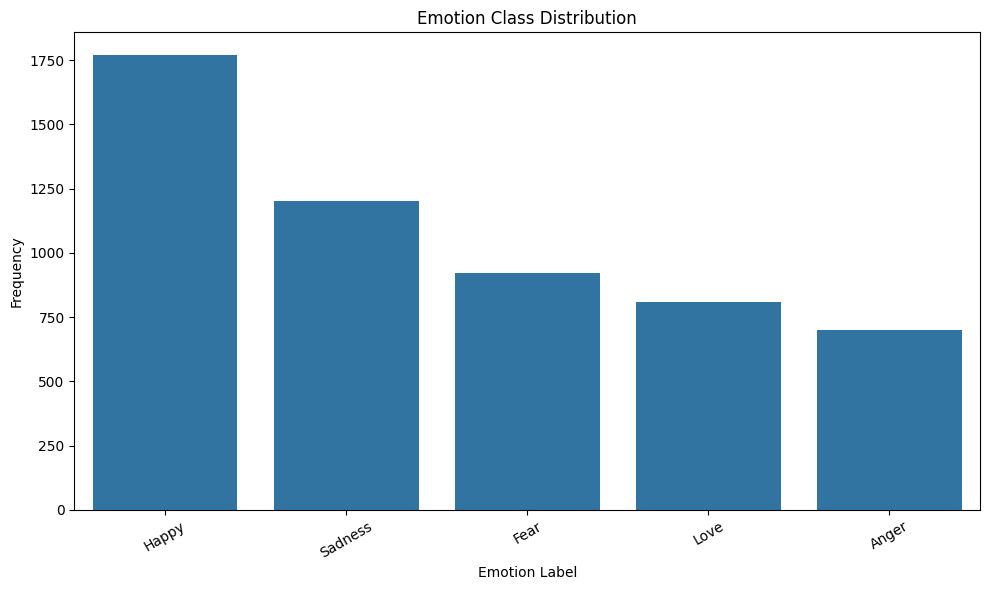

### Text Length Descriptive Statistics

,character_length,word_length
count,5400.00,5400.00
mean,103.81,16.10
std,98.26,15.65
min,3.00,1.00
25%,44.00,7.00
50%,78.00,12.00
75%,128.00,20.00
max,1058.00,184.00


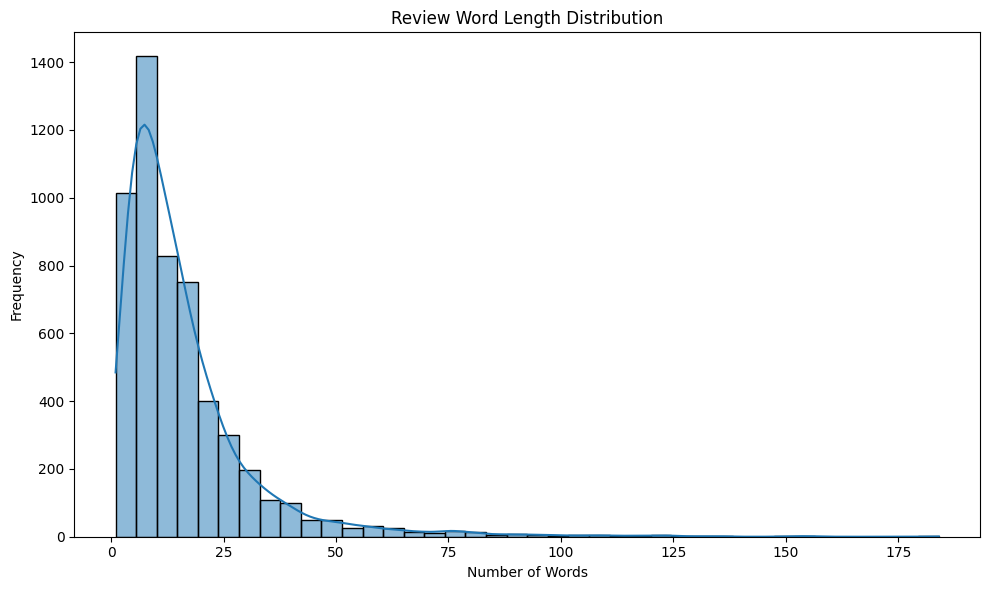

### Average Text Length by Emotion Label

,Emotion,character_length,word_length
0,Anger,111.83,18.01
1,Fear,137.25,22.05
2,Happy,84.81,12.50
3,Love,96.28,14.06
4,Sadness,106.58,17.09


In [16]:
# =============================================================================
# Program Title: Exploratory Data Analysis for Emotion Classification
# =============================================================================

# Keterangan:
# Cell ini melakukan EDA untuk memahami struktur data, missing value, duplikasi,
# distribusi kelas, dan panjang teks. Output dibuat dalam bentuk tabel dan grafik
# agar dapat digunakan dalam laporan penelitian.

display(Markdown("## Exploratory Data Analysis"))

# Salin data untuk analisis agar data asli tetap terjaga
eda_df = df.copy()

# Normalisasi tipe data dasar
eda_df[TEXT_COL] = eda_df[TEXT_COL].astype(str)
eda_df[LABEL_COL] = eda_df[LABEL_COL].astype(str)

# Tambahkan fitur panjang teks
eda_df["character_length"] = eda_df[TEXT_COL].apply(len)
eda_df["word_length"] = eda_df[TEXT_COL].apply(lambda x: len(x.split()))

# Ringkasan dataset
overview_table = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Text Column",
        "Label Column",
        "Number of Classes",
        "Missing Text Values",
        "Missing Label Values",
        "Duplicate Text Records"
    ],
    "Value": [
        eda_df.shape[0],
        eda_df.shape[1],
        TEXT_COL,
        LABEL_COL,
        eda_df[LABEL_COL].nunique(),
        eda_df[TEXT_COL].isna().sum(),
        eda_df[LABEL_COL].isna().sum(),
        eda_df.duplicated(subset=[TEXT_COL]).sum()
    ]
})

display(Markdown("### Dataset Overview"))
display(overview_table)

overview_table.to_csv(f"{TABLE_DIR}/dataset_overview.csv", index=False)

# Distribusi kelas
class_distribution = (
    eda_df[LABEL_COL]
    .value_counts()
    .rename_axis("Emotion Label")
    .reset_index(name="Frequency")
)

class_distribution["Percentage"] = (
    class_distribution["Frequency"] / class_distribution["Frequency"].sum() * 100
).round(2)

display(Markdown("### Emotion Class Distribution"))
display(class_distribution)

class_distribution.to_csv(f"{TABLE_DIR}/emotion_class_distribution.csv", index=False)

# Rasio imbalance
max_class = class_distribution["Frequency"].max()
min_class = class_distribution["Frequency"].min()
imbalance_ratio = round(max_class / min_class, 3)

print("Imbalance ratio:", imbalance_ratio)

# Grafik distribusi kelas
plt.figure(figsize=(10, 6))
sns.barplot(
    data=class_distribution,
    x="Emotion Label",
    y="Frequency"
)
plt.title("Emotion Class Distribution")
plt.xlabel("Emotion Label")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/emotion_class_distribution.png", dpi=300)
plt.show()

# Statistik panjang teks
length_summary = eda_df[["character_length", "word_length"]].describe().round(2)
display(Markdown("### Text Length Descriptive Statistics"))
display(length_summary)

length_summary.to_csv(f"{TABLE_DIR}/text_length_statistics.csv")

# Grafik distribusi panjang kata
plt.figure(figsize=(10, 6))
sns.histplot(eda_df["word_length"], bins=40, kde=True)
plt.title("Review Word Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/review_word_length_distribution.png", dpi=300)
plt.show()

# Rata-rata panjang teks per kelas
length_by_class = (
    eda_df.groupby(LABEL_COL)[["character_length", "word_length"]]
    .mean()
    .round(2)
    .reset_index()
)

display(Markdown("### Average Text Length by Emotion Label"))
display(length_by_class)

length_by_class.to_csv(f"{TABLE_DIR}/average_text_length_by_emotion.csv", index=False)

In [17]:
# =============================================================================
# Program Title: Text Cleaning and Research-Ready Dataset Preparation
# =============================================================================

# Keterangan:
# Cell ini membersihkan teks ulasan dari noise dasar seperti URL, angka,
# simbol, dan spasi berlebih. Preprocessing dilakukan secara sederhana dan
# transparan agar mudah direplikasi dalam laporan penelitian.

display(Markdown("## Text Cleaning and Data Preparation"))

def clean_text(text):
    """
    Fungsi ini melakukan pembersihan teks secara konservatif.
    Tujuannya bukan mengubah makna, tetapi mengurangi noise teknis.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Seleksi kolom utama dan hilangkan nilai kosong
model_df = df[[TEXT_COL, LABEL_COL]].copy()
model_df.columns = ["text", "label"]

model_df["text"] = model_df["text"].astype(str)
model_df["label"] = model_df["label"].astype(str)

model_df = model_df.dropna(subset=["text", "label"])
model_df = model_df[model_df["text"].str.strip().str.len() > 0]

# Hapus duplikasi teks agar evaluasi lebih bersih
before_duplicate_removal = model_df.shape[0]
model_df = model_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
after_duplicate_removal = model_df.shape[0]

model_df["clean_text"] = model_df["text"].apply(clean_text)
model_df = model_df[model_df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Records before duplicate removal:", before_duplicate_removal)
print("Records after duplicate removal:", after_duplicate_removal)
print("Final modeling records:", model_df.shape[0])

display(model_df.head())

# Simpan data bersih untuk audit penelitian
model_df.to_csv(f"{ARTIFACT_DIR}/clean_prdect_emotion_dataset.csv", index=False)

## Text Cleaning and Data Preparation

Records before duplicate removal: 5400
Records after duplicate removal: 5305
Final modeling records: 5305


,text,label,clean_text
0,Alhamdulillah berfungsi dengan baik. Packaging...,Happy,alhamdulillah berfungsi dengan baik packaging ...
1,"barang bagus dan respon cepat, harga bersaing ...",Happy,barang bagus dan respon cepat harga bersaing d...
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy,barang bagus berfungsi dengan baik seler ramah...
3,bagus sesuai harapan penjual nya juga ramah. t...,Happy,bagus sesuai harapan penjual nya juga ramah tr...
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy,barang bagus pengemasan aman dapat berfungsi d...


In [18]:
# =============================================================================
# Program Title: Stratified Dataset Splitting
# =============================================================================

# Keterangan:
# Split dilakukan secara stratified agar proporsi label emosi tetap seimbang
# antara train, validation, dan test. Ini penting untuk menjaga validitas evaluasi.

display(Markdown("## Stratified Train, Validation, and Test Split"))

X = model_df["clean_text"]
y = model_df["label"]

if y.value_counts().min() < 3:
    raise ValueError(
        "At least one class has fewer than 3 samples. Stratified split is not reliable."
    )

# Split 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

split_table = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test"],
    "Records": [len(X_train), len(X_val), len(X_test)],
    "Percentage": [
        round(len(X_train) / len(X) * 100, 2),
        round(len(X_val) / len(X) * 100, 2),
        round(len(X_test) / len(X) * 100, 2)
    ]
})

display(split_table)
split_table.to_csv(f"{TABLE_DIR}/dataset_split_summary.csv", index=False)

# Validasi distribusi label per subset
distribution_check = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Validation": y_val.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
}).round(4)

display(Markdown("### Stratified Label Distribution Check"))
display(distribution_check)

distribution_check.to_csv(f"{TABLE_DIR}/stratified_label_distribution_check.csv")

## Stratified Train, Validation, and Test Split

,Subset,Records,Percentage
0,Train,3713,69.99
1,Validation,796,15.00
2,Test,796,15.00


### Stratified Label Distribution Check

,Full Dataset,Train,Validation,Test
label,,,,
Anger,0.1272,0.1274,0.1269,0.1269
Fear,0.1681,0.1681,0.1683,0.1683
Happy,0.3304,0.3305,0.3304,0.3304
Love,0.1508,0.1508,0.1508,0.1508
Sadness,0.2234,0.2233,0.2236,0.2236


## Baseline Model: TF-IDF + Multiclass Logistic Regression

### Baseline Model Metrics

,Model,Validation Accuracy,Validation Macro F1,Test Accuracy,Test Macro F1,Test Weighted F1
0,TF-IDF + Multiclass Logistic Regression,0.6043,0.5796,0.603,0.5785,0.6092


### Baseline Classification Report

,precision,recall,f1-score,support
Anger,0.4779,0.5347,0.5047,101.000
Fear,0.4467,0.5000,0.4718,134.000
Happy,0.8219,0.6844,0.7469,263.000
Love,0.5573,0.6083,0.5817,120.000
Sadness,0.5792,0.5955,0.5873,178.000
accuracy,0.6030,0.6030,0.6030,0.603
macro avg,0.5766,0.5846,0.5785,796.000
weighted avg,0.6209,0.6030,0.6092,796.000


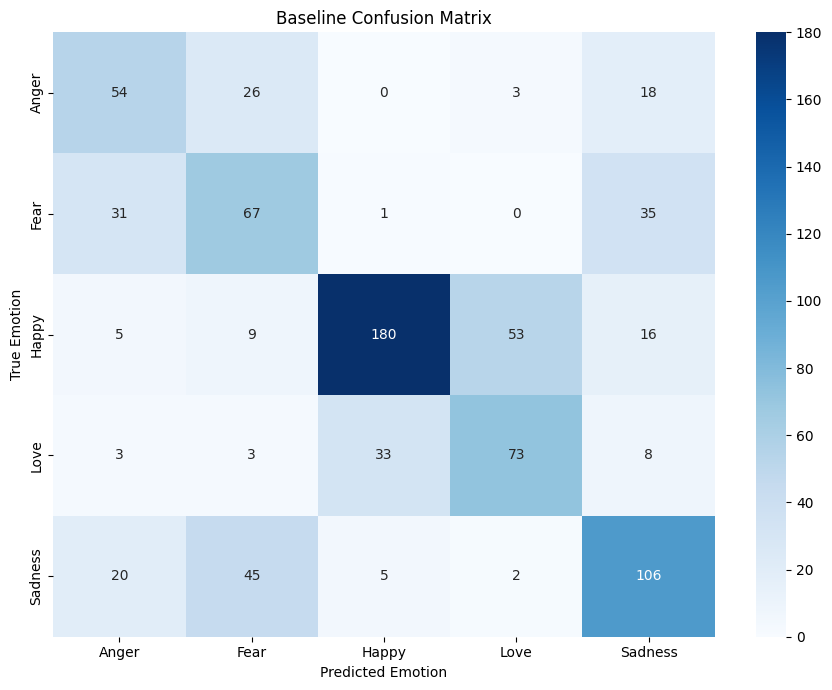

Joblib model saved at: /content/prdect_emotion_research/artifacts/emotion_tfidf_logreg_joblib.pkl


In [21]:
# =============================================================================
# Program Title: Baseline Machine Learning Model with Joblib Serialization
# =============================================================================

# Keterangan:
# Model baseline menggunakan TF-IDF dan Logistic Regression.
# Karena dataset PRDECT-ID memiliki lebih dari dua kelas emosi, solver "liblinear"
# tidak digunakan. Solver "lbfgs" dipilih karena mendukung klasifikasi multiclass.
# Parameter "multi_class" tidak digunakan karena pada versi scikit-learn terbaru
# parameter tersebut sudah tidak tersedia atau tidak direkomendasikan.

display(Markdown("## Baseline Model: TF-IDF + Multiclass Logistic Regression"))

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED,
    n_jobs=-1
)

baseline_model.fit(X_train_tfidf, y_train)

# Evaluasi validation dan test
val_pred = baseline_model.predict(X_val_tfidf)
test_pred = baseline_model.predict(X_test_tfidf)

baseline_metrics = {
    "Model": "TF-IDF + Multiclass Logistic Regression",
    "Validation Accuracy": accuracy_score(y_val, val_pred),
    "Validation Macro F1": f1_score(y_val, val_pred, average="macro", zero_division=0),
    "Test Accuracy": accuracy_score(y_test, test_pred),
    "Test Macro F1": f1_score(y_test, test_pred, average="macro", zero_division=0),
    "Test Weighted F1": f1_score(y_test, test_pred, average="weighted", zero_division=0)
}

baseline_metrics_df = pd.DataFrame([baseline_metrics]).round(4)

display(Markdown("### Baseline Model Metrics"))
display(baseline_metrics_df)

baseline_metrics_df.to_csv(f"{TABLE_DIR}/baseline_model_metrics.csv", index=False)

# Classification report
baseline_report = pd.DataFrame(
    classification_report(y_test, test_pred, output_dict=True, zero_division=0)
).transpose().round(4)

display(Markdown("### Baseline Classification Report"))
display(baseline_report)

baseline_report.to_csv(f"{TABLE_DIR}/baseline_classification_report.csv")

# Confusion matrix
labels_sorted = sorted(y.unique())

plt.figure(figsize=(9, 7))
sns.heatmap(
    confusion_matrix(y_test, test_pred, labels=labels_sorted),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/baseline_confusion_matrix.png", dpi=300)
plt.show()

# Simpan model joblib
joblib_artifact = {
    "tfidf": tfidf,
    "model": baseline_model,
    "labels": labels_sorted,
    "cleaning_note": "Input text must be processed using the same clean_text function before vectorization."
}

joblib_path = f"{ARTIFACT_DIR}/emotion_tfidf_logreg_joblib.pkl"
joblib.dump(joblib_artifact, joblib_path)

print("Joblib model saved at:", joblib_path)

In [22]:
# =============================================================================
# Program Title     : Deep Learning Emotion Classification Using CNN-BiLSTM
# Short Description : This cell builds and trains a CNN-BiLSTM model for
#                     multiclass emotion classification using cleaned PRDECT-ID
#                     review texts.
# =============================================================================

# Keterangan:
# Cell ini membangun model deep learning berbasis CNN-BiLSTM.
# CNN digunakan untuk menangkap pola lokal dalam teks, misalnya kombinasi kata
# pendek yang sering muncul pada ekspresi emosi. BiLSTM digunakan untuk memahami
# urutan kata dari dua arah sehingga konteks teks dapat dipelajari lebih baik.
# Untuk menjaga integritas eksperimen, tokenizer hanya dilatih pada data train
# agar tidak terjadi data leakage dari validation atau test set.

display(Markdown("## Deep Learning Model: CNN-BiLSTM"))

# =============================================================================
# 1. Import Library Tambahan
# =============================================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Conv1D,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# =============================================================================
# 2. Reproducibility Control
# =============================================================================

# Keterangan:
# Seed digunakan agar hasil eksperimen lebih konsisten ketika dijalankan ulang.
# Meskipun demikian, hasil deep learning tetap dapat sedikit berbeda karena
# faktor GPU dan operasi paralel.

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# =============================================================================
# 3. Label Encoding
# =============================================================================

# Keterangan:
# Label emosi berbentuk teks diubah menjadi angka karena model deep learning
# memerlukan target numerik untuk proses training.

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Detected emotion classes:", list(label_encoder.classes_))
print("Number of emotion classes:", num_classes)

# =============================================================================
# 4. Tokenization and Padding
# =============================================================================

# Keterangan:
# Tokenizer hanya di-fit pada data training agar tidak terjadi kebocoran informasi.
# Panjang sequence ditentukan dari persentil ke-95 panjang teks training agar
# tidak terlalu pendek dan tidak terlalu boros memori.

X_train_text = X_train.astype(str).tolist()
X_val_text = X_val.astype(str).tolist()
X_test_text = X_test.astype(str).tolist()

MAX_WORDS = 20000

train_word_lengths = pd.Series(X_train_text).apply(lambda text: len(text.split()))
MAX_LEN = int(np.percentile(train_word_lengths, 95))

# Batas panjang sequence dibuat adaptif tetapi tetap terkendali.
MAX_LEN = max(30, min(MAX_LEN, 200))

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_val_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Maximum sequence length:", MAX_LEN)
print("Train sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

# =============================================================================
# 5. Handling Class Imbalance
# =============================================================================

# Keterangan:
# Class weight digunakan untuk mengurangi dominasi kelas mayoritas.
# Strategi ini penting karena distribusi label emosi sering kali tidak seimbang.

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train_enc), class_weights_array)
}

print("Class weights:", class_weights)

# =============================================================================
# 6. CNN-BiLSTM Model Architecture
# =============================================================================

# Keterangan:
# Arsitektur dibuat moderat untuk menekan risiko overfitting.
# Dropout, SpatialDropout1D, dan regularisasi L2 digunakan sebagai mekanisme
# pengendalian kompleksitas model.

inputs = Input(shape=(MAX_LEN,), name="input_tokens")

x = Embedding(
    input_dim=vocab_size,
    output_dim=128,
    name="embedding_layer"
)(inputs)

x = SpatialDropout1D(
    rate=0.20,
    name="spatial_dropout_layer"
)(x)

x = Conv1D(
    filters=128,
    kernel_size=5,
    padding="same",
    activation="relu",
    name="convolution_layer"
)(x)

x = MaxPooling1D(
    pool_size=2,
    name="max_pooling_layer"
)(x)

x = Bidirectional(
    LSTM(
        units=64,
        dropout=0.20,
        recurrent_dropout=0.00
    ),
    name="bidirectional_lstm_layer"
)(x)

x = Dense(
    units=64,
    activation="relu",
    kernel_regularizer=l2(1e-4),
    name="dense_regularized_layer"
)(x)

x = Dropout(
    rate=0.50,
    name="dropout_layer"
)(x)

outputs = Dense(
    units=num_classes,
    activation="softmax",
    name="emotion_output_layer"
)(x)

deep_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN_BiLSTM_Emotion_Classifier"
)

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

display(Markdown("### CNN-BiLSTM Model Summary"))
deep_model.summary()

# =============================================================================
# 7. Training Configuration
# =============================================================================

# Keterangan:
# EarlyStopping menghentikan pelatihan ketika validation loss tidak membaik.
# ReduceLROnPlateau menurunkan learning rate jika model mulai stagnan.
# Keduanya digunakan untuk mengurangi risiko overfitting dan membantu stabilitas
# proses training.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# =============================================================================
# 8. Model Training
# =============================================================================

history = deep_model.fit(
    X_train_seq,
    y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

display(Markdown("### CNN-BiLSTM Training Completed"))

print("Training completed successfully.")
print("Best validation accuracy:", round(max(history.history["val_accuracy"]), 4))
print("Best validation loss:", round(min(history.history["val_loss"]), 4))

## Deep Learning Model: CNN-BiLSTM

Detected emotion classes: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']
Number of emotion classes: 5
Vocabulary size used: 6856
Maximum sequence length: 43
Train sequence shape: (3713, 43)
Validation sequence shape: (796, 43)
Test sequence shape: (796, 43)
Class weights: {0: 1.5699788583509513, 1: 1.1900641025641026, 2: 0.6052159739201304, 3: 1.3260714285714286, 4: 0.8957780458383595}


### CNN-BiLSTM Model Summary

Model: "CNN_BiLSTM_Emotion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 43)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Embedding)     │ (None, 43, 128)        │       877,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_layer           │ (None, 43, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolution_layer (Conv1D)      │ (None, 43, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer               │ (None, 21, 128)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_layer        │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_regularized_layer (Dense) │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_output_layer (Dense)    │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 1,067,013 (4.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.3054 - loss: 1.4808 - val_accuracy: 0.4812 - val_loss: 1.1127 - learning_rate: 0.0010
Epoch 2/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.4565 - loss: 1.1046 - val_accuracy: 0.5616 - val_loss: 0.9698 - learning_rate: 0.0010
Epoch 3/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.6297 - loss: 0.8450 - val_accuracy: 0.6018 - val_loss: 0.9253 - learning_rate: 0.0010
Epoch 4/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7641 - loss: 0.6314 - val_accuracy: 0.5967 - val_loss: 1.0738 - learning_rate: 0.0010
Epoch 5/25
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8157 - loss: 0.5143
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8416 - loss: 0.4595 - val_accuracy: 0.5754 - val_loss: 1.2820 - learning_rate: 0.0010
Epoch 6/25
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8982 - loss: 

### CNN-BiLSTM Training Completed

Training completed successfully.
Best validation accuracy: 0.6018
Best validation loss: 0.9253


In [26]:
# =============================================================================
# Program Title     : Balanced CNN-BiLSTM Revision After Underfitting
# Short Description : This cell revises the previous anti-overfitting model by
#                     moderately increasing model capacity, reducing excessive
#                     dropout, and extending training with controlled early
#                     stopping.
# =============================================================================

# Keterangan:
# Diagnosis sebelumnya menunjukkan underfitting, yaitu training accuracy dan
# validation accuracy sama-sama rendah. Kondisi ini biasanya terjadi ketika model
# terlalu sederhana, dropout terlalu besar, regularisasi terlalu kuat, atau durasi
# training belum cukup. Oleh karena itu, revisi ini menaikkan kapasitas model
# secara moderat tanpa mengubah data train, validation, dan test.

display(Markdown("## Balanced CNN-BiLSTM Revision After Underfitting"))

# =============================================================================
# 1. Import Library
# =============================================================================

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Conv1D,
    MaxPooling1D,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# =============================================================================
# 2. Reproducibility Control
# =============================================================================

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# =============================================================================
# 3. Label Encoding
# =============================================================================

# Keterangan:
# Label encoder hanya di-fit pada data train untuk menjaga konsistensi dan
# menghindari kebocoran informasi dari validation/test ke proses training.

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Detected emotion classes:", list(label_encoder.classes_))
print("Number of emotion classes:", num_classes)

# =============================================================================
# 4. Tokenization and Padding
# =============================================================================

# Keterangan:
# Tokenizer hanya dilatih pada data training. Panjang sequence dikembalikan ke
# persentil ke-95 agar model memperoleh konteks teks yang lebih cukup dibanding
# revisi anti-overfitting sebelumnya.

X_train_text = X_train.astype(str).tolist()
X_val_text = X_val.astype(str).tolist()
X_test_text = X_test.astype(str).tolist()

MAX_WORDS = 20000

train_word_lengths = pd.Series(X_train_text).apply(lambda text: len(str(text).split()))
MAX_LEN = int(np.percentile(train_word_lengths, 95))

# Batas panjang sequence tetap dikontrol agar tidak terlalu boros memori.
MAX_LEN = max(30, min(MAX_LEN, 180))

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_val_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Maximum sequence length:", MAX_LEN)
print("Train sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

# =============================================================================
# 5. Handling Class Imbalance
# =============================================================================

# Keterangan:
# Class weight tetap digunakan karena dataset klasifikasi emosi sering memiliki
# distribusi kelas yang tidak sepenuhnya seimbang. Strategi ini membantu model
# memperhatikan kelas minoritas selama proses training.

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_enc),
    y=y_train_enc
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train_enc), class_weights_array)
}

print("Class weights:", class_weights)

# =============================================================================
# 6. Balanced CNN-BiLSTM Architecture
# =============================================================================

# Keterangan:
# Revisi ini menyeimbangkan dua masalah:
# 1. Model awal cenderung overfitting.
# 2. Model anti-overfitting terlalu kuat dan menjadi underfitting.
#
# Karena itu, kapasitas dinaikkan secara moderat:
# - Embedding dimension: 64 -> 96
# - CNN filters: 64 -> 96
# - LSTM units: 32 -> 48
# - Dropout akhir: 0.60 -> 0.40
# - Regularisasi L2 dibuat lebih ringan

inputs = Input(shape=(MAX_LEN,), name="input_tokens")

x = Embedding(
    input_dim=vocab_size,
    output_dim=96,
    embeddings_regularizer=l2(1e-6),
    name="embedding_layer"
)(inputs)

x = SpatialDropout1D(
    rate=0.25,
    name="spatial_dropout_layer"
)(x)

x = Conv1D(
    filters=96,
    kernel_size=3,
    padding="same",
    activation="relu",
    kernel_regularizer=l2(1e-5),
    name="convolution_layer"
)(x)

x = MaxPooling1D(
    pool_size=2,
    name="max_pooling_layer"
)(x)

x = Bidirectional(
    LSTM(
        units=48,
        dropout=0.20,
        recurrent_dropout=0.00,
        kernel_regularizer=l2(1e-5)
    ),
    name="bidirectional_lstm_layer"
)(x)

x = Dense(
    units=48,
    activation="relu",
    kernel_regularizer=l2(1e-4),
    name="dense_regularized_layer"
)(x)

x = Dropout(
    rate=0.40,
    name="dropout_layer"
)(x)

outputs = Dense(
    units=num_classes,
    activation="softmax",
    name="emotion_output_layer"
)(x)

deep_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="Balanced_CNN_BiLSTM_Emotion_Classifier"
)

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

display(Markdown("### Balanced CNN-BiLSTM Model Summary"))
deep_model.summary()

# =============================================================================
# 7. Training Configuration
# =============================================================================

# Keterangan:
# Patience dinaikkan kembali agar model memiliki kesempatan belajar lebih baik,
# tetapi EarlyStopping tetap digunakan agar training berhenti jika validation loss
# tidak membaik. ReduceLROnPlateau membantu optimasi ketika model mulai stagnan.

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# =============================================================================
# 8. Balanced Model Training
# =============================================================================

history = deep_model.fit(
    X_train_seq,
    y_train_enc,
    validation_data=(X_val_seq, y_val_enc),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

display(Markdown("### Balanced CNN-BiLSTM Training Completed"))

print("Training completed successfully.")
print("Best validation accuracy:", round(max(history.history["val_accuracy"]), 4))
print("Best validation loss:", round(min(history.history["val_loss"]), 4))
print("Final training accuracy:", round(history.history["accuracy"][-1], 4))
print("Final validation accuracy:", round(history.history["val_accuracy"][-1], 4))
print("Final accuracy gap:", round(history.history["accuracy"][-1] - history.history["val_accuracy"][-1], 4))

## Balanced CNN-BiLSTM Revision After Underfitting

Detected emotion classes: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']
Number of emotion classes: 5
Vocabulary size used: 6856
Maximum sequence length: 43
Train sequence shape: (3713, 43)
Validation sequence shape: (796, 43)
Test sequence shape: (796, 43)
Class weights: {0: 1.5699788583509513, 1: 1.1900641025641026, 2: 0.6052159739201304, 3: 1.3260714285714286, 4: 0.8957780458383595}


### Balanced CNN-BiLSTM Model Summary

Model: "Balanced_CNN_BiLSTM_Emotion_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 43)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Embedding)     │ (None, 43, 96)         │       658,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_layer           │ (None, 43, 96)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolution_layer (Conv1D)      │ (None, 43, 96)         │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer               │ (None, 21, 96)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_layer        │ (None, 96)             │        55,680 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_regularized_layer (Dense) │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_output_layer (Dense)    │ (None, 5)              │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 746,501 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.2723 - loss: 1.5573 - val_accuracy: 0.4585 - val_loss: 1.2418 - learning_rate: 7.0000e-04
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.4053 - loss: 1.1810 - val_accuracy: 0.4686 - val_loss: 1.0631 - learning_rate: 7.0000e-04
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5209 - loss: 0.9959 - val_accuracy: 0.5528 - val_loss: 1.0349 - learning_rate: 7.0000e-04
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6499 - loss: 0.8029 - val_accuracy: 0.5905 - val_loss: 1.0297 - learning_rate: 7.0000e-04
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7533 - loss: 0.6547 - val_accuracy: 0.5992 - val_loss: 1.0137 - learning_rate: 7.0000e-04
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8279 - loss: 0.4862 - val_accuracy: 0.5854 - val_loss: 1.1503 - learning_rate: 7.0000e-04
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - 

### Balanced CNN-BiLSTM Training Completed

Training completed successfully.
Best validation accuracy: 0.5992
Best validation loss: 1.0137
Final training accuracy: 0.9383
Final validation accuracy: 0.5678
Final accuracy gap: 0.3705


## Evaluation and Diagnostic Analysis for Balanced CNN-BiLSTM

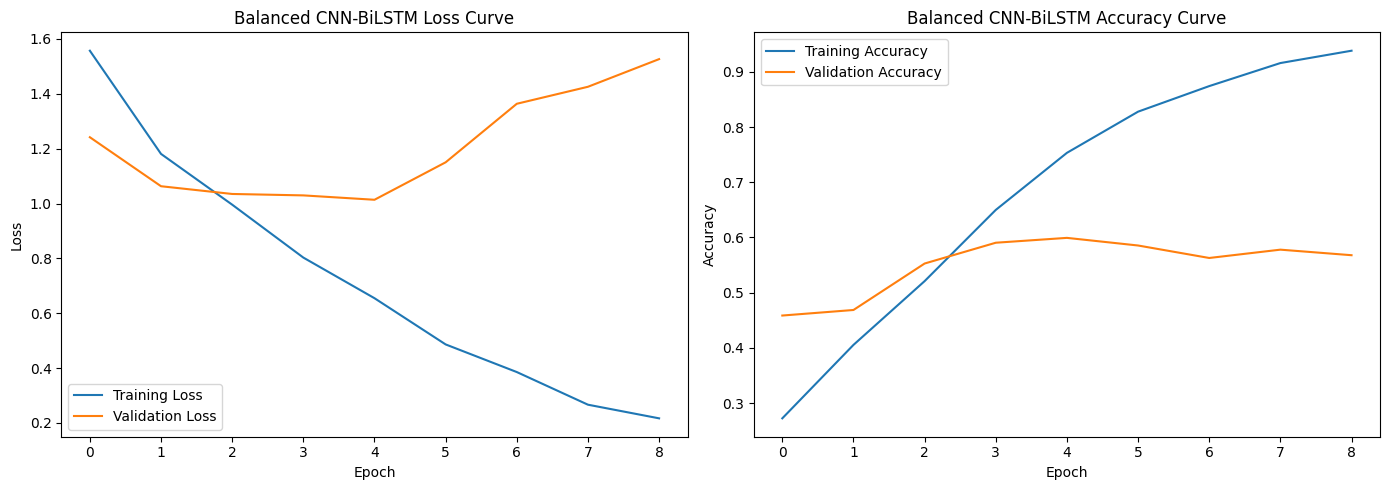

### Balanced CNN-BiLSTM Test Metrics

,Model,Test Accuracy,Test Precision Macro,Test Recall Macro,Test Macro F1,Test Weighted F1
0,Balanced CNN-BiLSTM,0.5704,0.5408,0.5171,0.5234,0.5665


### Balanced CNN-BiLSTM Classification Report

,precision,recall,f1-score,support
Anger,0.5075,0.3366,0.4048,101.0000
Fear,0.3901,0.4104,0.4000,134.0000
Happy,0.7399,0.7681,0.7537,263.0000
Love,0.5758,0.4750,0.5205,120.0000
Sadness,0.4907,0.5955,0.5381,178.0000
accuracy,0.5704,0.5704,0.5704,0.5704
macro avg,0.5408,0.5171,0.5234,796.0000
weighted avg,0.5711,0.5704,0.5665,796.0000


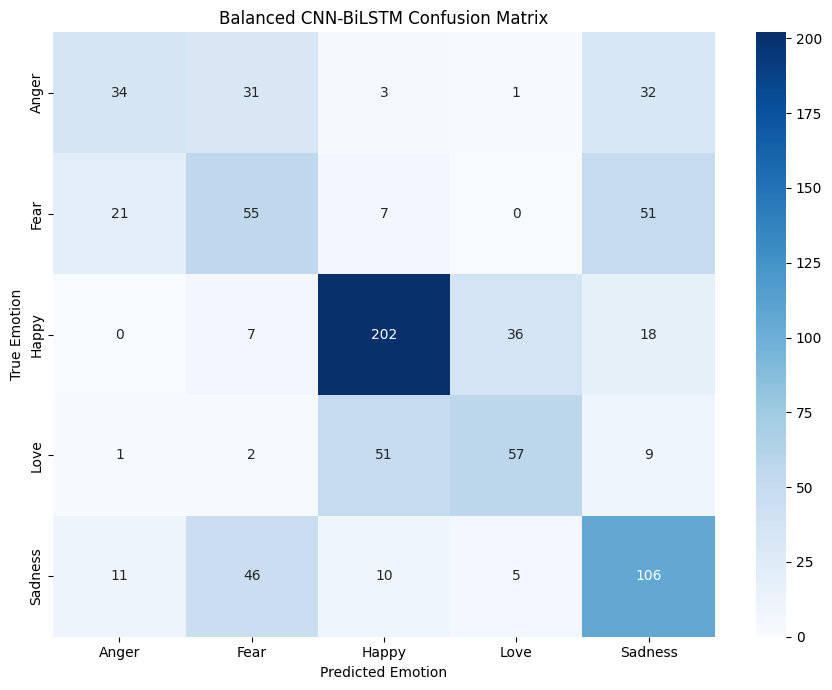

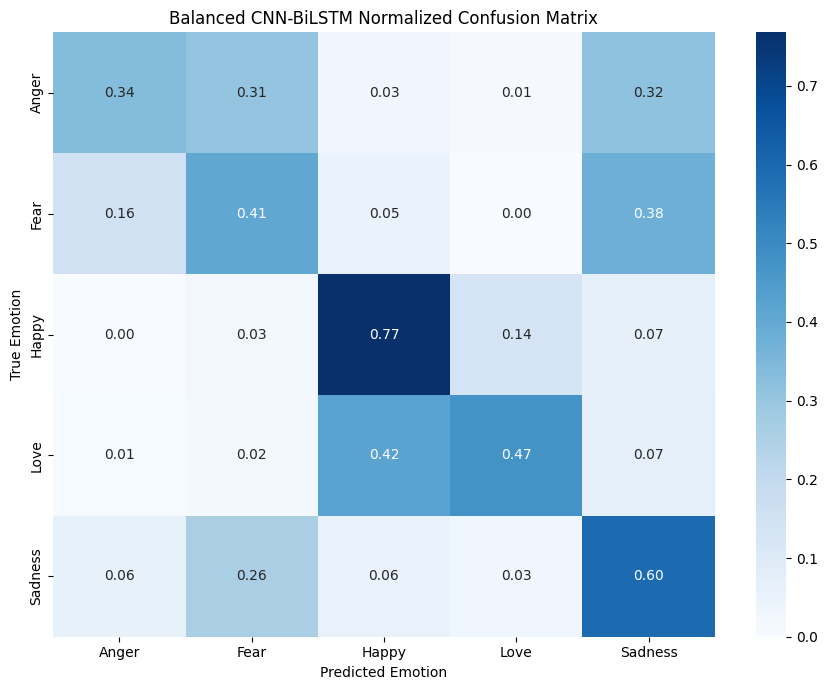

### Prediction Analysis Sample

,Text,True Emotion,Predicted Emotion,Prediction Confidence,Correct Prediction
0,barangnya lumayan tp kecewa sama respon penjua...,Sadness,Sadness,0.981670,True
1,barang gak dikirim gak usah ngadain flash sale...,Fear,Anger,0.570455,False
2,wae keren alatnya berasa jadi pengrajin rokok ...,Happy,Happy,0.834664,True
3,ini seller tidak berkualitas jawab lama dan ba...,Fear,Fear,0.638392,True
4,fitting tidak sesuai dgn celana pendek umumnya,Fear,Fear,0.537462,True
5,makasih ka barang ok,Happy,Happy,0.711289,True
6,belanja kedua kalinya selalu puas pengiriman l...,Happy,Love,0.674128,False
7,kualitasnya mengecewakan blm dipake sudah rusa...,Sadness,Sadness,0.897098,True
8,lagi musim hujan tidak dibungkus yang aman dan...,Sadness,Happy,0.755042,False
9,pertama liat flash salenya langsung beli ndak ...,Fear,Sadness,0.491440,False


### High-Confidence Misclassification Samples

,Text,True Emotion,Predicted Emotion,Prediction Confidence,Correct Prediction
727,bahannya adem lembut cocok dipakai dalam ruang...,Love,Happy,0.969811,False
707,harga terjangkau recomended warna sesuai pengi...,Love,Happy,0.965262,False
236,barang sesuai pesanan mantap dipakai sdh prnh ...,Love,Happy,0.961854,False
587,pesan kurir instan posisi rumah saya di bintar...,Anger,Sadness,0.958661,False
788,desainnya mewah warnanya cantik ukuran sesuai ...,Love,Happy,0.958584,False
566,positive seller fast respon fast delivery rapi...,Love,Happy,0.952656,False
102,kualitas barang dibanding harga nya hanya so s...,Anger,Happy,0.949047,False
319,bahannya tebal bahannya lembut warnanya cantik...,Love,Happy,0.944020,False
669,gimana bisa miring begitu plus udh di wanti al...,Fear,Sadness,0.943714,False
244,murah sesuai harga tapi barangnya kerass bange...,Fear,Happy,0.942501,False


### Learning Curve Diagnostic Table

,Indicator,Value
0,Final Training Accuracy,0.9383
1,Final Validation Accuracy,0.5678
2,Best Validation Accuracy,0.5992
3,Final Training Loss,0.2166
4,Final Validation Loss,1.5266
5,Best Validation Loss,1.0137
6,Accuracy Gap,0.3705
7,Loss Gap,1.3100


### Diagnostic Interpretation

- Potential Overfitting: training performance is substantially better than validation performance.
- Recommended Revision: increase dropout moderately, strengthen L2 regularization, reduce LSTM units, or apply validated text augmentation.


### Research Interpretation Template


The Balanced CNN-BiLSTM model achieved a Test Accuracy of 0.5704
and a Test Macro F1-score of 0.5234.

The balanced architecture was designed after observing underfitting in the
previous revision. Model capacity was moderately increased while regularization
was kept under control. Therefore, the main evaluation focus should be placed on
Macro F1, normalized confusion matrix, and the stability of the validation curve.

If the accuracy gap remains small and the validation loss is stable, the model
shows better generalization. However, if the Macro F1-score is still lower than
the baseline TF-IDF Logistic Regression model, the baseline model should remain
the preferred model for early REST API deployment because it is simpler, more
stable, and easier to reproduce.

Balanced CNN-BiLSTM evaluation completed successfully.


In [27]:
# =============================================================================
# Program Title     : Evaluation and Diagnostic Analysis for Balanced CNN-BiLSTM
# Short Description : This cell evaluates the balanced CNN-BiLSTM model using
#                     test data, visualizes model performance, and diagnoses
#                     overfitting or underfitting based on learning curves.
# =============================================================================

# Keterangan:
# Cell ini digunakan setelah menjalankan Cell 8R2. Evaluasi dilakukan pada test
# set yang tidak digunakan dalam training maupun validation. Dengan demikian,
# hasil evaluasi dapat digunakan sebagai dasar analisis generalisasi model secara
# objektif dan dapat direproduksi.

display(Markdown("## Evaluation and Diagnostic Analysis for Balanced CNN-BiLSTM"))

# =============================================================================
# 1. Import Evaluation Libraries
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =============================================================================
# 2. Learning Curve Visualization
# =============================================================================

# Keterangan:
# Learning curve digunakan untuk melihat pola pembelajaran model.
# Jika training accuracy tinggi tetapi validation accuracy rendah, model cenderung
# overfitting. Jika keduanya rendah, model cenderung underfitting.

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Balanced CNN-BiLSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Balanced CNN-BiLSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/balanced_cnn_bilstm_learning_curves.png", dpi=300)
plt.show()

# =============================================================================
# 3. Test Set Prediction
# =============================================================================

# Keterangan:
# Prediksi dilakukan pada data test. Probabilitas tertinggi dari softmax
# digunakan sebagai kelas prediksi akhir.

deep_pred_prob = deep_model.predict(X_test_seq, verbose=0)

deep_pred_enc = np.argmax(deep_pred_prob, axis=1)
deep_true_enc = y_test_enc

deep_pred = label_encoder.inverse_transform(deep_pred_enc)
deep_true = label_encoder.inverse_transform(deep_true_enc)

# =============================================================================
# 4. Evaluation Metrics
# =============================================================================

# Keterangan:
# Macro F1 digunakan sebagai metrik penting karena memberikan bobot yang sama
# kepada setiap kelas emosi. Ini relevan untuk dataset yang memiliki potensi
# imbalance antar kelas.

deep_metrics = {
    "Model": "Balanced CNN-BiLSTM",
    "Test Accuracy": accuracy_score(deep_true, deep_pred),
    "Test Precision Macro": precision_score(deep_true, deep_pred, average="macro", zero_division=0),
    "Test Recall Macro": recall_score(deep_true, deep_pred, average="macro", zero_division=0),
    "Test Macro F1": f1_score(deep_true, deep_pred, average="macro", zero_division=0),
    "Test Weighted F1": f1_score(deep_true, deep_pred, average="weighted", zero_division=0)
}

deep_metrics_df = pd.DataFrame([deep_metrics]).round(4)

display(Markdown("### Balanced CNN-BiLSTM Test Metrics"))
display(deep_metrics_df)

deep_metrics_df.to_csv(
    f"{TABLE_DIR}/balanced_deep_learning_model_metrics.csv",
    index=False
)

# =============================================================================
# 5. Classification Report
# =============================================================================

# Keterangan:
# Classification report menampilkan precision, recall, dan F1-score per kelas.
# Bagian ini penting untuk melihat kelas emosi mana yang masih sulit diprediksi.

classification_report_df = pd.DataFrame(
    classification_report(
        deep_true,
        deep_pred,
        labels=list(label_encoder.classes_),
        output_dict=True,
        zero_division=0
    )
).transpose().round(4)

display(Markdown("### Balanced CNN-BiLSTM Classification Report"))
display(classification_report_df)

classification_report_df.to_csv(
    f"{TABLE_DIR}/balanced_deep_learning_classification_report.csv"
)

# =============================================================================
# 6. Confusion Matrix
# =============================================================================

# Keterangan:
# Confusion matrix menunjukkan jumlah prediksi benar dan salah pada setiap kelas.
# Visualisasi ini membantu menemukan pola kesalahan model secara lebih spesifik.

labels_sorted = list(label_encoder.classes_)

cm = confusion_matrix(
    deep_true,
    deep_pred,
    labels=labels_sorted
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Balanced CNN-BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/balanced_cnn_bilstm_confusion_matrix.png", dpi=300)
plt.show()

# =============================================================================
# 7. Normalized Confusion Matrix
# =============================================================================

# Keterangan:
# Confusion matrix ternormalisasi digunakan untuk membaca proporsi kesalahan
# relatif pada setiap kelas, bukan hanya jumlah absolutnya.

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Balanced CNN-BiLSTM Normalized Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/balanced_cnn_bilstm_normalized_confusion_matrix.png", dpi=300)
plt.show()

# =============================================================================
# 8. Prediction Confidence Analysis
# =============================================================================

# Keterangan:
# Analisis confidence membantu melihat tingkat keyakinan model. Kesalahan dengan
# confidence tinggi perlu dianalisis karena dapat menunjukkan ambiguitas teks,
# bias kelas, atau representasi fitur yang belum optimal.

prediction_analysis_df = pd.DataFrame({
    "Text": X_test.reset_index(drop=True),
    "True Emotion": deep_true,
    "Predicted Emotion": deep_pred,
    "Prediction Confidence": deep_pred_prob.max(axis=1)
})

prediction_analysis_df["Correct Prediction"] = (
    prediction_analysis_df["True Emotion"] == prediction_analysis_df["Predicted Emotion"]
)

display(Markdown("### Prediction Analysis Sample"))
display(prediction_analysis_df.head(10))

prediction_analysis_df.to_csv(
    f"{TABLE_DIR}/balanced_deep_learning_prediction_analysis.csv",
    index=False
)

error_samples_df = (
    prediction_analysis_df[prediction_analysis_df["Correct Prediction"] == False]
    .sort_values(by="Prediction Confidence", ascending=False)
    .head(10)
)

display(Markdown("### High-Confidence Misclassification Samples"))
display(error_samples_df)

error_samples_df.to_csv(
    f"{TABLE_DIR}/balanced_high_confidence_misclassification_samples.csv",
    index=False
)

# =============================================================================
# 9. Overfitting and Underfitting Diagnostic Rule
# =============================================================================

# Keterangan:
# Diagnosis berikut bersifat heuristik. Tujuannya membantu membaca pola umum
# learning curve secara logis, bukan menggantikan analisis metrik formal.

def diagnose_learning_curve(history_obj):
    train_acc = history_obj.history["accuracy"][-1]
    val_acc = history_obj.history["val_accuracy"][-1]
    train_loss = history_obj.history["loss"][-1]
    val_loss = history_obj.history["val_loss"][-1]

    best_val_acc = max(history_obj.history["val_accuracy"])
    best_val_loss = min(history_obj.history["val_loss"])

    acc_gap = train_acc - val_acc
    loss_gap = val_loss - train_loss

    diagnostic_table = pd.DataFrame({
        "Indicator": [
            "Final Training Accuracy",
            "Final Validation Accuracy",
            "Best Validation Accuracy",
            "Final Training Loss",
            "Final Validation Loss",
            "Best Validation Loss",
            "Accuracy Gap",
            "Loss Gap"
        ],
        "Value": [
            train_acc,
            val_acc,
            best_val_acc,
            train_loss,
            val_loss,
            best_val_loss,
            acc_gap,
            loss_gap
        ]
    }).round(4)

    notes = []

    if acc_gap > 0.12 and loss_gap > 0.10:
        notes.append(
            "Potential Overfitting: training performance is substantially better than validation performance."
        )
        notes.append(
            "Recommended Revision: increase dropout moderately, strengthen L2 regularization, reduce LSTM units, or apply validated text augmentation."
        )
    elif train_acc < 0.60 and val_acc < 0.60:
        notes.append(
            "Potential Underfitting: both training and validation accuracy are relatively low."
        )
        notes.append(
            "Recommended Revision: increase model capacity carefully, reduce dropout, improve preprocessing, or use pretrained Indonesian language models."
        )
    elif val_loss > train_loss and acc_gap > 0.07:
        notes.append(
            "Mild Generalization Gap: the model shows limited overfitting but not at a severe level."
        )
        notes.append(
            "Recommended Revision: compare Macro F1 with the baseline model before applying further changes."
        )
    else:
        notes.append(
            "Learning Pattern Acceptable: no strong overfitting or underfitting signal was detected."
        )

    return diagnostic_table, notes

diagnosis_table, diagnosis_notes = diagnose_learning_curve(history)

display(Markdown("### Learning Curve Diagnostic Table"))
display(diagnosis_table)

diagnosis_table.to_csv(
    f"{TABLE_DIR}/balanced_cnn_bilstm_learning_curve_diagnosis.csv",
    index=False
)

display(Markdown("### Diagnostic Interpretation"))
for note in diagnosis_notes:
    print("-", note)

# =============================================================================
# 10. Research Interpretation Template
# =============================================================================

# Keterangan:
# Narasi ini menggunakan angka asli dari runtime program. Dengan demikian, laporan
# tidak menggunakan data palsu dan dapat dipertanggungjawabkan secara akademik.

display(Markdown("### Research Interpretation Template"))

print(
    f"""
The Balanced CNN-BiLSTM model achieved a Test Accuracy of {deep_metrics['Test Accuracy']:.4f}
and a Test Macro F1-score of {deep_metrics['Test Macro F1']:.4f}.

The balanced architecture was designed after observing underfitting in the
previous revision. Model capacity was moderately increased while regularization
was kept under control. Therefore, the main evaluation focus should be placed on
Macro F1, normalized confusion matrix, and the stability of the validation curve.

If the accuracy gap remains small and the validation loss is stable, the model
shows better generalization. However, if the Macro F1-score is still lower than
the baseline TF-IDF Logistic Regression model, the baseline model should remain
the preferred model for early REST API deployment because it is simpler, more
stable, and easier to reproduce.
"""
)

print("Balanced CNN-BiLSTM evaluation completed successfully.")

## Comparative Model Performance Summary

### Model Comparison Table

,Model,Test Accuracy,Test Macro F1,Test Weighted F1
0,TF-IDF + Multiclass Logistic Regression,0.6030,0.5785,0.6092
1,Balanced CNN-BiLSTM,0.5704,0.5234,0.5665


### Best Model Selection

Best model based on Test Macro F1: TF-IDF + Multiclass Logistic Regression
Best Test Macro F1: 0.5785


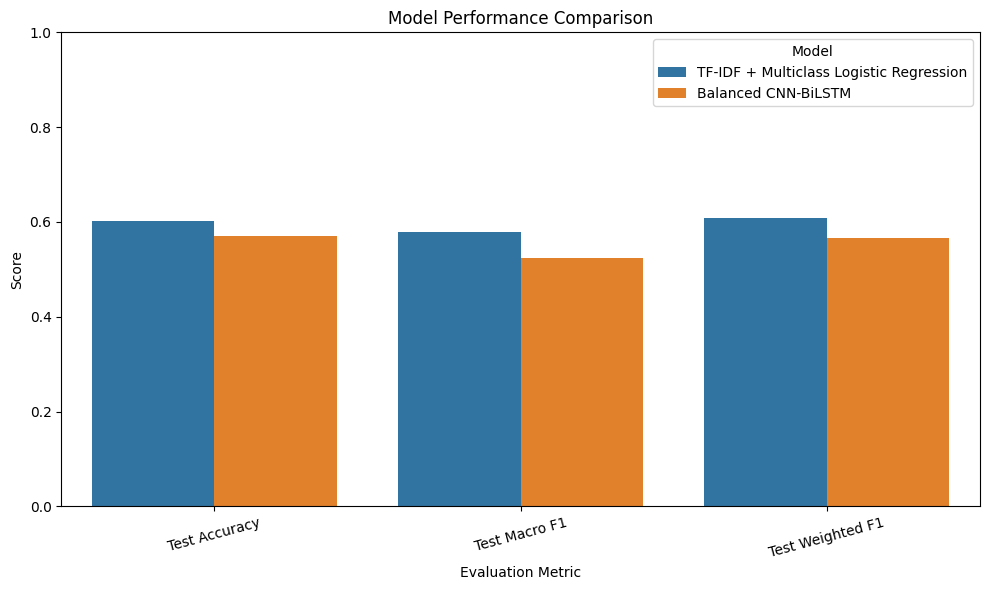

### Macro F1 Difference Analysis

,Comparison,Difference
0,Deep Learning Macro F1 - Baseline Macro F1,-0.0551


### Deployment Recommendation

The baseline TF-IDF + Logistic Regression model is recommended for the initial REST API deployment because it achieved the best Macro F1 score or remained more stable and simpler for reproducible implementation.


### Research Interpretation Template


The comparative evaluation shows that the TF-IDF + Multiclass Logistic Regression achieved the highest
Test Macro F1-score of 0.5785. Macro F1 was selected as the primary
metric because it gives equal importance to all emotion classes and is therefore
more appropriate for multiclass emotion classification with potential class
imbalance.

The Macro F1 difference between the Balanced CNN-BiLSTM model and the baseline
model was -0.0551. This difference should be interpreted
carefully. If the improvement is small, the simpler baseline model may be more
appropriate for early deployment because it is faster, more reproducible, and
easier to serialize using joblib. If the improvement is substantial, the deep
learning model can be justified as the primary research model.

Deployment recommendation:
The baseline TF-IDF + Logistic Regression model is recommended for the initial REST API deployment because it achieved the best Macro F1 score or remained more stable and simpler for reproducible i

In [28]:
# =============================================================================
# Program Title     : Comparative Model Performance Summary
# Short Description : This cell compares the baseline machine learning model and
#                     the balanced CNN-BiLSTM model using research-standard
#                     classification metrics.
# =============================================================================

# Keterangan:
# Cell ini membandingkan performa model baseline dan model deep learning.
# Fokus utama evaluasi adalah Macro F1 karena metrik ini lebih adil untuk
# klasifikasi multi-kelas dengan potensi imbalance. Accuracy tetap dilaporkan,
# tetapi tidak dijadikan satu-satunya dasar keputusan model terbaik.

display(Markdown("## Comparative Model Performance Summary"))

# =============================================================================
# 1. Validate Required Metrics
# =============================================================================

# Keterangan:
# Validasi dilakukan untuk memastikan Cell 7 dan Cell 9 sudah dijalankan.
# baseline_metrics berasal dari Cell 7, sedangkan deep_metrics berasal dari Cell 9.

required_objects = ["baseline_metrics", "deep_metrics"]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_objects)
        + ". Please run Cell 7 and Cell 9 before running Cell 10."
    )

# =============================================================================
# 2. Build Comparison Table
# =============================================================================

comparison_table = pd.DataFrame([
    {
        "Model": baseline_metrics.get("Model", "TF-IDF + Logistic Regression"),
        "Test Accuracy": baseline_metrics.get("Test Accuracy"),
        "Test Macro F1": baseline_metrics.get("Test Macro F1"),
        "Test Weighted F1": baseline_metrics.get("Test Weighted F1")
    },
    {
        "Model": deep_metrics.get("Model", "Balanced CNN-BiLSTM"),
        "Test Accuracy": deep_metrics.get("Test Accuracy"),
        "Test Macro F1": deep_metrics.get("Test Macro F1"),
        "Test Weighted F1": deep_metrics.get("Test Weighted F1")
    }
]).round(4)

display(Markdown("### Model Comparison Table"))
display(comparison_table)

comparison_table.to_csv(
    f"{TABLE_DIR}/model_comparison_summary.csv",
    index=False
)

# =============================================================================
# 3. Determine Best Model by Macro F1
# =============================================================================

# Keterangan:
# Macro F1 dipilih sebagai kriteria utama karena memperlakukan setiap kelas
# emosi secara setara. Ini penting untuk menjaga integritas evaluasi pada data
# yang berpotensi imbalance.

best_model_row = comparison_table.sort_values(
    by="Test Macro F1",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_macro_f1 = best_model_row["Test Macro F1"]

display(Markdown("### Best Model Selection"))
print("Best model based on Test Macro F1:", best_model_name)
print("Best Test Macro F1:", best_macro_f1)

# =============================================================================
# 4. Visualization of Model Comparison
# =============================================================================

comparison_melted = comparison_table.melt(
    id_vars="Model",
    value_vars=["Test Accuracy", "Test Macro F1", "Test Weighted F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/model_performance_comparison.png", dpi=300)
plt.show()

# =============================================================================
# 5. Difference Analysis
# =============================================================================

# Keterangan:
# Selisih performa dihitung untuk membaca apakah model deep learning benar-benar
# memberikan peningkatan dibanding baseline. Jika peningkatannya kecil atau lebih
# rendah, baseline dapat lebih rasional digunakan untuk deployment awal.

baseline_macro_f1 = comparison_table.loc[
    comparison_table["Model"] == baseline_metrics.get("Model", "TF-IDF + Logistic Regression"),
    "Test Macro F1"
].values[0]

deep_macro_f1 = comparison_table.loc[
    comparison_table["Model"] == deep_metrics.get("Model", "Balanced CNN-BiLSTM"),
    "Test Macro F1"
].values[0]

macro_f1_difference = round(deep_macro_f1 - baseline_macro_f1, 4)

difference_table = pd.DataFrame({
    "Comparison": ["Deep Learning Macro F1 - Baseline Macro F1"],
    "Difference": [macro_f1_difference]
})

display(Markdown("### Macro F1 Difference Analysis"))
display(difference_table)

difference_table.to_csv(
    f"{TABLE_DIR}/macro_f1_difference_analysis.csv",
    index=False
)

# =============================================================================
# 6. Deployment Recommendation
# =============================================================================

# Keterangan:
# Rekomendasi deployment dibuat berdasarkan performa dan stabilitas praktis.
# Untuk REST API awal, baseline sering lebih stabil karena ringan, cepat, dan
# mudah disimpan dengan joblib. Deep learning dipilih jika peningkatan Macro F1
# cukup jelas dan learning curve stabil.

display(Markdown("### Deployment Recommendation"))

if best_model_name == baseline_metrics.get("Model", "TF-IDF + Logistic Regression"):
    deployment_recommendation = (
        "The baseline TF-IDF + Logistic Regression model is recommended for the "
        "initial REST API deployment because it achieved the best Macro F1 score "
        "or remained more stable and simpler for reproducible implementation."
    )
else:
    if macro_f1_difference >= 0.02:
        deployment_recommendation = (
            "The Balanced CNN-BiLSTM model is recommended as the main research "
            "model because it improves Macro F1 meaningfully over the baseline. "
            "However, REST API deployment should include the saved Keras model and "
            "its tokenizer/label encoder artifacts."
        )
    else:
        deployment_recommendation = (
            "Although the Balanced CNN-BiLSTM model performs slightly better, the "
            "improvement is small. The baseline model remains more practical for "
            "initial REST API deployment, while the deep learning model can be "
            "reported as an experimental comparison."
        )

print(deployment_recommendation)

# Simpan rekomendasi sebagai file teks untuk dokumentasi penelitian
with open(f"{TABLE_DIR}/deployment_recommendation.txt", "w") as file:
    file.write(deployment_recommendation)

# =============================================================================
# 7. Research Interpretation Template
# =============================================================================

# Keterangan:
# Template interpretasi ini menggunakan angka aktual dari hasil runtime.
# Dengan demikian, narasi laporan tidak mengandung hasil palsu.

display(Markdown("### Research Interpretation Template"))

print(
    f"""
The comparative evaluation shows that the {best_model_name} achieved the highest
Test Macro F1-score of {best_macro_f1:.4f}. Macro F1 was selected as the primary
metric because it gives equal importance to all emotion classes and is therefore
more appropriate for multiclass emotion classification with potential class
imbalance.

The Macro F1 difference between the Balanced CNN-BiLSTM model and the baseline
model was {macro_f1_difference:.4f}. This difference should be interpreted
carefully. If the improvement is small, the simpler baseline model may be more
appropriate for early deployment because it is faster, more reproducible, and
easier to serialize using joblib. If the improvement is substantial, the deep
learning model can be justified as the primary research model.

Deployment recommendation:
{deployment_recommendation}
"""
)

print("Model comparison completed successfully.")

In [29]:
# =============================================================================
# Program Title     : Model Saving and Reproducible Artifacts Export
# Short Description : This cell saves the selected models and preprocessing
#                     artifacts for reproducible inference and REST API deployment.
# =============================================================================

# Keterangan:
# Cell ini menyimpan seluruh artefak penting agar model dapat digunakan ulang
# tanpa training dari awal. Model baseline disimpan dengan joblib karena berbasis
# scikit-learn. Model deep learning disimpan dalam format .keras, sedangkan
# tokenizer dan label encoder disimpan dengan joblib.

display(Markdown("## Model Saving and Reproducible Artifacts Export"))

# =============================================================================
# 1. Validate Required Objects
# =============================================================================

required_objects = [
    "baseline_model",
    "tfidf",
    "deep_model",
    "tokenizer",
    "label_encoder",
    "MAX_LEN",
    "MAX_WORDS",
    "clean_text",
    "comparison_table"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_objects)
        + ". Please run previous cells before running Cell 11."
    )

# =============================================================================
# 2. Save Baseline Model with Joblib
# =============================================================================

# Keterangan:
# Baseline model disimpan bersama TF-IDF vectorizer dan daftar label.
# Format joblib sesuai untuk pipeline machine learning klasik dan REST API ringan.

baseline_joblib_path = f"{ARTIFACT_DIR}/emotion_tfidf_logreg_joblib.pkl"

baseline_artifact = {
    "model_type": "TF-IDF + Logistic Regression",
    "tfidf": tfidf,
    "model": baseline_model,
    "labels": sorted(list(y.unique())),
    "text_preprocessing": "clean_text function must be applied before TF-IDF transformation."
}

joblib.dump(baseline_artifact, baseline_joblib_path)

print("Baseline joblib artifact saved at:")
print(baseline_joblib_path)

# =============================================================================
# 3. Save Deep Learning Model
# =============================================================================

# Keterangan:
# Model Keras disimpan dalam format .keras. Format ini lebih sesuai untuk model
# TensorFlow/Keras dibanding memaksa seluruh model deep learning disimpan sebagai
# joblib.

deep_model_path = f"{ARTIFACT_DIR}/balanced_cnn_bilstm_model.keras"
deep_model.save(deep_model_path)

print("Deep learning Keras model saved at:")
print(deep_model_path)

# =============================================================================
# 4. Save Deep Learning Preprocessing Objects with Joblib
# =============================================================================

# Keterangan:
# Tokenizer, label encoder, dan parameter sequence wajib disimpan agar input baru
# diproses dengan cara yang sama seperti saat training.

deep_preprocessing_path = f"{ARTIFACT_DIR}/balanced_cnn_bilstm_preprocessing_joblib.pkl"

deep_preprocessing_artifact = {
    "model_type": "Balanced CNN-BiLSTM",
    "tokenizer": tokenizer,
    "label_encoder": label_encoder,
    "max_len": MAX_LEN,
    "max_words": MAX_WORDS,
    "labels": list(label_encoder.classes_),
    "text_preprocessing": "clean_text function must be applied before tokenization."
}

joblib.dump(deep_preprocessing_artifact, deep_preprocessing_path)

print("Deep learning preprocessing artifact saved at:")
print(deep_preprocessing_path)

# =============================================================================
# 5. Save Research Metadata
# =============================================================================

# Keterangan:
# Metadata eksperimen disimpan untuk dokumentasi ilmiah. File ini membantu
# pembaca memahami konfigurasi penelitian tanpa harus membaca seluruh notebook.

research_metadata = {
    "program_title": "Reproducible Emotion Classification and REST API Deployment",
    "dataset_source": "PRDECT-ID CSV workflow",
    "task": "Multiclass emotion classification",
    "text_column": TEXT_COL if "TEXT_COL" in globals() else "clean_text",
    "label_column": LABEL_COL if "LABEL_COL" in globals() else "label",
    "random_seed": SEED,
    "train_records": int(len(X_train)),
    "validation_records": int(len(X_val)),
    "test_records": int(len(X_test)),
    "baseline_artifact_path": baseline_joblib_path,
    "deep_model_path": deep_model_path,
    "deep_preprocessing_path": deep_preprocessing_path,
    "best_model_by_macro_f1": str(best_model_name) if "best_model_name" in globals() else None,
    "created_artifacts_directory": ARTIFACT_DIR
}

metadata_path = f"{ARTIFACT_DIR}/research_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(research_metadata, file, indent=4, ensure_ascii=False)

print("Research metadata saved at:")
print(metadata_path)

# =============================================================================
# 6. Artifact Summary Table
# =============================================================================

artifact_summary = pd.DataFrame({
    "Artifact": [
        "Baseline joblib model",
        "Deep learning Keras model",
        "Deep learning preprocessing joblib",
        "Research metadata"
    ],
    "Path": [
        baseline_joblib_path,
        deep_model_path,
        deep_preprocessing_path,
        metadata_path
    ],
    "Purpose": [
        "REST API deployment and fast inference",
        "Deep learning inference and research comparison",
        "Tokenizer, label encoder, and sequence configuration",
        "Reproducibility documentation"
    ]
})

display(Markdown("### Saved Artifact Summary"))
display(artifact_summary)

artifact_summary.to_csv(
    f"{TABLE_DIR}/saved_artifact_summary.csv",
    index=False
)

print("Model saving process completed successfully.")

## Model Saving and Reproducible Artifacts Export

Baseline joblib artifact saved at:
/content/prdect_emotion_research/artifacts/emotion_tfidf_logreg_joblib.pkl
Deep learning Keras model saved at:
/content/prdect_emotion_research/artifacts/balanced_cnn_bilstm_model.keras
Deep learning preprocessing artifact saved at:
/content/prdect_emotion_research/artifacts/balanced_cnn_bilstm_preprocessing_joblib.pkl
Research metadata saved at:
/content/prdect_emotion_research/artifacts/research_metadata.json


### Saved Artifact Summary

,Artifact,Path,Purpose
0,Baseline joblib model,/content/prdect_emotion_research/artifacts/emo...,REST API deployment and fast inference
1,Deep learning Keras model,/content/prdect_emotion_research/artifacts/bal...,Deep learning inference and research comparison
2,Deep learning preprocessing joblib,/content/prdect_emotion_research/artifacts/bal...,"Tokenizer, label encoder, and sequence configu..."
3,Research metadata,/content/prdect_emotion_research/artifacts/res...,Reproducibility documentation


Model saving process completed successfully.


In [30]:
# =============================================================================
# Program Title     : Manual Testing with 7 New Review Samples
# Short Description : This cell performs practical inference testing using seven
#                     new Indonesian product review samples to observe model
#                     behavior before REST API deployment.
# =============================================================================

# Keterangan:
# Cell ini menguji model pada 7 teks ulasan baru yang tidak berasal dari dataset
# training, validation, atau test. Pengujian ini bersifat praktis dan indikatif,
# bukan pengganti evaluasi formal pada test set. Tujuan utamanya adalah melihat
# apakah model dapat memberikan prediksi yang logis pada input baru.

display(Markdown("## Manual Testing with 7 New Review Samples"))

# =============================================================================
# 1. Validate Required Artifacts
# =============================================================================

required_objects = [
    "baseline_joblib_path",
    "clean_text"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise NameError(
        "The following required objects are missing: "
        + ", ".join(missing_objects)
        + ". Please run Cell 11 before running Cell 12."
    )

# =============================================================================
# 2. Load Saved Joblib Baseline Model
# =============================================================================

# Keterangan:
# Model dimuat dari file joblib yang sudah disimpan. Cara ini memastikan bahwa
# proses prediksi menggunakan artefak yang sama dengan yang akan digunakan pada
# tahap deployment REST API.

loaded_baseline_artifact = joblib.load(baseline_joblib_path)

loaded_tfidf = loaded_baseline_artifact["tfidf"]
loaded_model = loaded_baseline_artifact["model"]
loaded_labels = loaded_baseline_artifact["labels"]

print("Loaded joblib model successfully.")
print("Available labels:", loaded_labels)

# =============================================================================
# 3. Define Prediction Function
# =============================================================================

# Keterangan:
# Fungsi prediksi ini menjaga konsistensi preprocessing. Setiap teks baru
# dibersihkan menggunakan fungsi clean_text, kemudian diubah menjadi fitur TF-IDF,
# lalu diprediksi oleh model Logistic Regression.

def predict_new_reviews_with_joblib(texts):
    if isinstance(texts, str):
        texts = [texts]

    cleaned_texts = [clean_text(text) for text in texts]
    features = loaded_tfidf.transform(cleaned_texts)
    predicted_labels = loaded_model.predict(features)

    if hasattr(loaded_model, "predict_proba"):
        predicted_probabilities = loaded_model.predict_proba(features)
        confidence_scores = predicted_probabilities.max(axis=1)
    else:
        predicted_probabilities = None
        confidence_scores = np.array([np.nan] * len(texts))

    result_df = pd.DataFrame({
        "Original Review Text": texts,
        "Cleaned Review Text": cleaned_texts,
        "Predicted Emotion": predicted_labels,
        "Prediction Confidence": np.round(confidence_scores, 4)
    })

    return result_df

# =============================================================================
# 4. Prepare 7 New Review Samples
# =============================================================================

# Keterangan:
# Tujuh contoh berikut dibuat untuk mewakili kecenderungan emosi yang berbeda.
# Kolom Expected Semantic Tendency bukan label kebenaran formal, tetapi asumsi
# semantik untuk membantu interpretasi awal secara kualitatif.

manual_test_samples = pd.DataFrame({
    "New Review Text": [
        "Produk ini sangat bagus, kualitasnya memuaskan, dan saya sangat senang membelinya.",
        "Barang datang rusak, pelayanan buruk, saya benar-benar marah dengan pengalaman ini.",
        "Saya kecewa karena produk tidak sesuai deskripsi dan kualitasnya sangat rendah.",
        "Saya suka sekali dengan produk ini, rasanya ingin membeli lagi untuk keluarga.",
        "Saya takut barang ini tidak aman digunakan karena kemasannya terbuka saat diterima.",
        "Pengiriman cepat, produk berfungsi baik, dan hasilnya membuat saya puas.",
        "Saya sedih karena barang yang saya tunggu lama ternyata tidak bisa digunakan."
    ],
    "Expected Semantic Tendency": [
        "Happy",
        "Anger",
        "Sadness",
        "Love",
        "Fear",
        "Happy",
        "Sadness"
    ]
})

display(Markdown("### Manual Test Input Samples"))
display(manual_test_samples)

# =============================================================================
# 5. Run Manual Prediction
# =============================================================================

manual_prediction_df = predict_new_reviews_with_joblib(
    manual_test_samples["New Review Text"].tolist()
)

manual_result_df = pd.concat(
    [
        manual_test_samples.reset_index(drop=True),
        manual_prediction_df[["Cleaned Review Text", "Predicted Emotion", "Prediction Confidence"]]
    ],
    axis=1
)

# Bandingkan prediksi dengan kecenderungan semantik manual.
# Perbandingan ini hanya indikatif karena expected tendency bukan anotasi resmi.
manual_result_df["Indicative Semantic Match"] = (
    manual_result_df["Expected Semantic Tendency"].str.lower()
    == manual_result_df["Predicted Emotion"].astype(str).str.lower()
)

display(Markdown("### Manual Prediction Results"))
display(manual_result_df)

# =============================================================================
# 6. Manual Testing Summary
# =============================================================================

indicative_match_rate = manual_result_df["Indicative Semantic Match"].mean()

manual_summary = pd.DataFrame({
    "Evaluation Type": ["Indicative Manual Testing"],
    "Number of New Samples": [len(manual_result_df)],
    "Indicative Match Rate": [round(indicative_match_rate, 4)],
    "Important Note": [
        "This is a qualitative sanity check and must not replace formal test-set evaluation."
    ]
})

display(Markdown("### Manual Testing Summary"))
display(manual_summary)

# =============================================================================
# 7. Save Manual Testing Results
# =============================================================================

manual_result_path = f"{TABLE_DIR}/manual_testing_7_new_review_samples.csv"
manual_summary_path = f"{TABLE_DIR}/manual_testing_summary.csv"

manual_result_df.to_csv(manual_result_path, index=False)
manual_summary.to_csv(manual_summary_path, index=False)

print("Manual testing results saved at:")
print(manual_result_path)

print("Manual testing summary saved at:")
print(manual_summary_path)

# =============================================================================
# 8. Academic Interpretation Template
# =============================================================================

# Keterangan:
# Narasi ini membantu penulisan laporan. Hasil manual testing tidak boleh
# digunakan sebagai bukti utama performa model, melainkan sebagai validasi
# praktis awal sebelum deployment.

display(Markdown("### Academic Interpretation Template"))

print(
    f"""
The manual inference test was conducted using seven new Indonesian product review
samples that were not part of the training, validation, or test subsets. The model
produced an indicative semantic match rate of {indicative_match_rate:.4f}.

This result should be interpreted as a practical sanity check rather than a
formal performance metric. The formal model performance must still be based on
the held-out test set using accuracy, precision, recall, Macro F1-score, and the
confusion matrix.

Manual testing is useful before REST API deployment because it helps verify that
the saved joblib model, preprocessing function, and prediction workflow operate
consistently on new input texts.
"""
)

print("Manual testing completed successfully.")

## Manual Testing with 7 New Review Samples

Loaded joblib model successfully.
Available labels: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']


### Manual Test Input Samples

,New Review Text,Expected Semantic Tendency
0,"Produk ini sangat bagus, kualitasnya memuaskan...",Happy
1,"Barang datang rusak, pelayanan buruk, saya ben...",Anger
2,Saya kecewa karena produk tidak sesuai deskrip...,Sadness
3,"Saya suka sekali dengan produk ini, rasanya in...",Love
4,Saya takut barang ini tidak aman digunakan kar...,Fear
5,"Pengiriman cepat, produk berfungsi baik, dan h...",Happy
6,Saya sedih karena barang yang saya tunggu lama...,Sadness


### Manual Prediction Results

...

### Manual Testing Summary

,Evaluation Type,Number of New Samples,Indicative Match Rate,Important Note
0,Indicative Manual Testing,7,1.0,This is a qualitative sanity check and must no...


Manual testing results saved at:
/content/prdect_emotion_research/tables/manual_testing_7_new_review_samples.csv
Manual testing summary saved at:
/content/prdect_emotion_research/tables/manual_testing_summary.csv


### Academic Interpretation Template


The manual inference test was conducted using seven new Indonesian product review
samples that were not part of the training, validation, or test subsets. The model
produced an indicative semantic match rate of 1.0000.

This result should be interpreted as a practical sanity check rather than a
formal performance metric. The formal model performance must still be based on
the held-out test set using accuracy, precision, recall, Macro F1-score, and the
confusion matrix.

Manual testing is useful before REST API deployment because it helps verify that
the saved joblib model, preprocessing function, and prediction workflow operate
consistently on new input texts.

Manual testing completed successfully.


In [32]:
# =============================================================================
# Program Title     : Simple REST API for Emotion Classification in Colab
# Short Description : This cell creates a FastAPI application file that loads the
#                     saved joblib model and provides an emotion prediction
#                     endpoint for Indonesian product review texts.
# =============================================================================

# Keterangan:
# Cell ini membuat aplikasi REST API sederhana untuk deployment awal di Google
# Colab. Model yang digunakan adalah baseline TF-IDF + Logistic Regression karena
# lebih ringan, stabil, mudah disimpan dengan joblib, dan cocok untuk praktik
# REST API tahap awal.
#
# Endpoint utama:
# - GET  /        : mengecek status API
# - POST /predict : menerima daftar teks dan mengembalikan prediksi emosi

display(Markdown("## Simple REST API for Emotion Classification in Colab"))

# =============================================================================
# 1. Validate Saved Joblib Artifact
# =============================================================================

# Keterangan:
# Validasi dilakukan untuk memastikan file model joblib sudah tersedia sebelum
# membuat aplikasi API.

if "baseline_joblib_path" not in globals():
    raise NameError(
        "baseline_joblib_path is missing. Please run Cell 11 before running Cell 13."
    )

if not os.path.exists(baseline_joblib_path):
    raise FileNotFoundError(
        f"Joblib artifact was not found at: {baseline_joblib_path}. "
        "Please run Cell 11 again."
    )

print("Joblib artifact is available:")
print(baseline_joblib_path)

# =============================================================================
# 2. Create FastAPI Application File
# =============================================================================

# Keterangan:
# File app.py dibuat secara otomatis. Fungsi clean_text ditulis ulang di dalam
# app.py agar API tetap dapat berjalan mandiri tanpa bergantung pada state notebook.

app_code = f'''
import re
import joblib
import numpy as np
from typing import List
from fastapi import FastAPI
from pydantic import BaseModel

ARTIFACT_PATH = r"{baseline_joblib_path}"

artifact = joblib.load(ARTIFACT_PATH)
tfidf = artifact["tfidf"]
model = artifact["model"]
labels = artifact.get("labels", [])

app = FastAPI(
    title="Emotion Classification REST API",
    description="A simple REST API for Indonesian product review emotion classification using a TF-IDF Logistic Regression model.",
    version="1.0.0"
)

class PredictionRequest(BaseModel):
    texts: List[str]

def clean_text(text):
    """
    Membersihkan teks input dengan prosedur yang sama seperti tahap training.
    """
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"@\\w+|#\\w+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

@app.get("/")
def root():
    return {{
        "message": "Emotion Classification REST API is running.",
        "model": artifact.get("model_type", "TF-IDF + Logistic Regression"),
        "available_labels": labels,
        "prediction_endpoint": "/predict"
    }}

@app.post("/predict")
def predict(request: PredictionRequest):
    if not request.texts:
        return {{
            "total_predictions": 0,
            "results": [],
            "warning": "No input texts were provided."
        }}

    cleaned_texts = [clean_text(text) for text in request.texts]
    features = tfidf.transform(cleaned_texts)
    predicted_labels = model.predict(features)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        confidence_scores = probabilities.max(axis=1)
    else:
        confidence_scores = [None] * len(predicted_labels)

    results = []

    for original_text, cleaned_text, label, confidence in zip(
        request.texts,
        cleaned_texts,
        predicted_labels,
        confidence_scores
    ):
        results.append({{
            "original_text": original_text,
            "cleaned_text": cleaned_text,
            "predicted_emotion": str(label),
            "confidence": None if confidence is None else float(np.round(confidence, 4))
        }})

    return {{
        "total_predictions": len(results),
        "results": results
    }}
'''

app_path = "/content/app.py"

with open(app_path, "w", encoding="utf-8") as file:
    file.write(app_code)

print("FastAPI application file created successfully:")
print(app_path)

# =============================================================================
# 3. Display API File Preview
# =============================================================================

# Keterangan:
# Preview sebagian isi file ditampilkan untuk memastikan app.py berhasil dibuat.

with open(app_path, "r", encoding="utf-8") as file:
    preview_lines = file.readlines()[:40]

print("\n".join(preview_lines))

## Simple REST API for Emotion Classification in Colab

Joblib artifact is available:
/content/prdect_emotion_research/artifacts/emotion_tfidf_logreg_joblib.pkl
FastAPI application file created successfully:
/content/app.py


import re

import joblib

import numpy as np

from typing import List

from fastapi import FastAPI

from pydantic import BaseModel



ARTIFACT_PATH = r"/content/prdect_emotion_research/artifacts/emotion_tfidf_logreg_joblib.pkl"



artifact = joblib.load(ARTIFACT_PATH)

tfidf = artifact["tfidf"]

model = artifact["model"]

labels = artifact.get("labels", [])



app = FastAPI(

    title="Emotion Classification REST API",

    description="A simple REST API for Indonesian product review emotion classification using a TF-IDF Logistic Regression model.",

    version="1.0.0"

)



class PredictionRequest(BaseModel):

    texts: List[str]



def clean_text(text):

    """

    Membersihkan teks input dengan prosedur yang sama seperti tahap training.

    """

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+"

In [33]:
# =============================================================================
# Program Title     : Run REST API Server in Google Colab
# Short Description : This cell runs the FastAPI application locally inside the
#                     Colab runtime using Uvicorn and a background thread.
# =============================================================================

# Keterangan:
# Cell ini menjalankan REST API secara lokal pada runtime Colab.
# Server dijalankan menggunakan background thread agar notebook tetap dapat
# digunakan untuk cell berikutnya, termasuk pengujian endpoint /predict.
#
# Alamat lokal API:
# - Root endpoint       : http://127.0.0.1:8000
# - Prediction endpoint : http://127.0.0.1:8000/predict

display(Markdown("## Run REST API Server in Google Colab"))

# =============================================================================
# 1. Import Required Libraries
# =============================================================================

import os
import time
import socket
import threading
import nest_asyncio
import uvicorn

# =============================================================================
# 2. Validate FastAPI App File
# =============================================================================

app_path = "/content/app.py"

if not os.path.exists(app_path):
    raise FileNotFoundError(
        "The FastAPI application file was not found at /content/app.py. "
        "Please run Cell 13 before running Cell 14."
    )

print("FastAPI application file found:")
print(app_path)

# =============================================================================
# 3. Check Port Availability
# =============================================================================

# Keterangan:
# Fungsi ini mengecek apakah port 8000 sudah digunakan. Jika port aktif,
# kemungkinan server sebelumnya sudah berjalan sehingga tidak perlu menjalankan
# ulang server baru.

def is_port_in_use(host="127.0.0.1", port=8000):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        return sock.connect_ex((host, port)) == 0

HOST = "127.0.0.1"
PORT = 8000

if is_port_in_use(HOST, PORT):
    print(f"Port {PORT} is already in use. The REST API server may already be running.")
else:
    # =========================================================================
    # 4. Run Uvicorn Server in Background Thread
    # =========================================================================

    # Keterangan:
    # Server dijalankan dalam thread daemon agar tidak menghentikan eksekusi
    # notebook. Parameter log_level dibuat info agar status server tetap terbaca.

    def run_api_server():
        uvicorn.run(
            "app:app",
            host=HOST,
            port=PORT,
            log_level="info"
        )

    api_thread = threading.Thread(target=run_api_server)
    api_thread.daemon = True
    api_thread.start()

    # Beri waktu singkat agar server siap menerima request.
    time.sleep(3)

# =============================================================================
# 5. Confirm Server Status
# =============================================================================

if is_port_in_use(HOST, PORT):
    print("REST API server is running successfully.")
    print(f"Root endpoint       : http://{HOST}:{PORT}")
    print(f"Prediction endpoint : http://{HOST}:{PORT}/predict")
else:
    raise RuntimeError(
        "REST API server failed to start. Please check the app.py file and prior cells."
    )

## Run REST API Server in Google Colab

FastAPI application file found:
/content/app.py


INFO:     Started server process [1623]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


REST API server is running successfully.
Root endpoint       : http://127.0.0.1:8000
Prediction endpoint : http://127.0.0.1:8000/predict


In [34]:
# =============================================================================
# Program Title     : Test REST API Prediction Endpoint
# Short Description : This cell sends sample Indonesian product review texts to
#                     the FastAPI /predict endpoint and displays the prediction
#                     response in a structured table.
# =============================================================================

# Keterangan:
# Cell ini menguji endpoint /predict menggunakan request POST.
# Jika server REST API berjalan dengan benar, response akan berisi prediksi emosi
# dan confidence score untuk setiap teks input. Pengujian ini penting untuk
# memastikan bahwa model joblib, preprocessing, dan endpoint API bekerja secara
# konsisten setelah deployment lokal di Colab.

display(Markdown("## Test REST API Prediction Endpoint"))

# =============================================================================
# 1. Import Required Libraries
# =============================================================================

import requests
import pandas as pd
from IPython.display import display, Markdown

# =============================================================================
# 2. Define API Endpoint
# =============================================================================

API_URL = "http://127.0.0.1:8000/predict"

# =============================================================================
# 3. Prepare Sample Payload
# =============================================================================

# Keterangan:
# Payload berisi beberapa teks ulasan baru. Format harus sesuai dengan skema API
# pada Cell 13, yaitu dictionary dengan key "texts" berisi list string.

payload = {
    "texts": [
        "Saya sangat puas dengan produk ini karena kualitasnya bagus dan pengirimannya cepat.",
        "Saya marah karena barang datang rusak dan tidak sesuai dengan deskripsi.",
        "Produk ini mengecewakan, saya sedih karena tidak bisa digunakan sama sekali.",
        "Saya suka sekali dengan produk ini dan ingin membelinya lagi.",
        "Saya takut produk ini tidak aman karena kemasannya terbuka saat diterima."
    ]
}

# =============================================================================
# 4. Send POST Request to REST API
# =============================================================================

try:
    response = requests.post(API_URL, json=payload, timeout=30)

    print("HTTP Status Code:", response.status_code)

    if response.status_code != 200:
        print("Response text:")
        print(response.text)
        raise RuntimeError(
            "REST API request failed. Please check whether Cell 14 server is running."
        )

    response_json = response.json()

except requests.exceptions.ConnectionError:
    raise ConnectionError(
        "Failed to connect to the REST API server. Please run Cell 14 first."
    )

except requests.exceptions.Timeout:
    raise TimeoutError(
        "REST API request timed out. Please check the server status and try again."
    )

# =============================================================================
# 5. Display Raw JSON Response
# =============================================================================

display(Markdown("### Raw API Response"))
display(response_json)

# =============================================================================
# 6. Convert API Response to Table
# =============================================================================

# Keterangan:
# Response JSON diubah menjadi tabel agar mudah dibaca dan dapat digunakan untuk
# dokumentasi laporan praktik deployment.

if "results" not in response_json:
    raise ValueError(
        "Invalid API response format. The key 'results' was not found."
    )

api_result_df = pd.DataFrame(response_json["results"])

display(Markdown("### API Prediction Results Table"))
display(api_result_df)

# =============================================================================
# 7. Save API Test Results
# =============================================================================

api_test_result_path = f"{TABLE_DIR}/rest_api_prediction_test_results.csv"
api_result_df.to_csv(api_test_result_path, index=False)

print("REST API prediction test results saved at:")
print(api_test_result_path)

# =============================================================================
# 8. Academic Interpretation Template
# =============================================================================

# Keterangan:
# Narasi ini digunakan untuk pembahasan praktik deployment. Hasil API harus
# dipahami sebagai uji fungsional endpoint, bukan evaluasi statistik formal.

display(Markdown("### Academic Interpretation Template"))

print(
    f"""
The REST API endpoint was tested using {len(payload['texts'])} new Indonesian
product review samples. The API returned structured prediction outputs containing
the original text, cleaned text, predicted emotion label, and confidence score.

This test confirms that the saved joblib model, TF-IDF vectorizer, preprocessing
procedure, and FastAPI endpoint can operate together in a reproducible inference
workflow. However, this endpoint test should be interpreted as a deployment
functionality check, not as a formal measurement of classification performance.
Formal performance evaluation must still rely on the held-out test set metrics
reported earlier.
"""
)

print("REST API endpoint test completed successfully.")

## Test REST API Prediction Endpoint

INFO:     127.0.0.1:33280 - "POST /predict HTTP/1.1" 200 OK
HTTP Status Code: 200


### Raw API Response

{'total_predictions': 5,
 'results': [{'original_text': 'Saya sangat puas dengan produk ini karena kualitasnya bagus dan pengirimannya cepat.',
   'cleaned_text': 'saya sangat puas dengan produk ini karena kualitasnya bagus dan pengirimannya cepat',
   'predicted_emotion': 'Love',
   'confidence': 0.4858},
  {'original_text': 'Saya marah karena barang datang rusak dan tidak sesuai dengan deskripsi.',
   'cleaned_text': 'saya marah karena barang datang rusak dan tidak sesuai dengan deskripsi',
   'predicted_emotion': 'Fear',
   'confidence': 0.4879},
  {'original_text': 'Produk ini mengecewakan, saya sedih karena tidak bisa digunakan sama sekali.',
   'cleaned_text': 'produk ini mengecewakan saya sedih karena tidak bisa digunakan sama sekali',
   'predicted_emotion': 'Sadness',
   'confidence': 0.5364},
  {'original_text': 'Saya suka sekali dengan produk ini dan ingin membelinya lagi.',
   'cleaned_text': 'saya suka sekali dengan produk ini dan ingin membelinya lagi',
   'predicted_emot

### API Prediction Results Table

,original_text,cleaned_text,predicted_emotion,confidence
0,Saya sangat puas dengan produk ini karena kual...,saya sangat puas dengan produk ini karena kual...,Love,0.4858
1,Saya marah karena barang datang rusak dan tida...,saya marah karena barang datang rusak dan tida...,Fear,0.4879
2,"Produk ini mengecewakan, saya sedih karena tid...",produk ini mengecewakan saya sedih karena tida...,Sadness,0.5364
3,Saya suka sekali dengan produk ini dan ingin m...,saya suka sekali dengan produk ini dan ingin m...,Love,0.5317
4,Saya takut produk ini tidak aman karena kemasa...,saya takut produk ini tidak aman karena kemasa...,Fear,0.4198


REST API prediction test results saved at:
/content/prdect_emotion_research/tables/rest_api_prediction_test_results.csv


### Academic Interpretation Template


The REST API endpoint was tested using 5 new Indonesian
product review samples. The API returned structured prediction outputs containing
the original text, cleaned text, predicted emotion label, and confidence score.

This test confirms that the saved joblib model, TF-IDF vectorizer, preprocessing
procedure, and FastAPI endpoint can operate together in a reproducible inference
workflow. However, this endpoint test should be interpreted as a deployment
functionality check, not as a formal measurement of classification performance.
Formal performance evaluation must still rely on the held-out test set metrics
reported earlier.

REST API endpoint test completed successfully.
